In [1]:
# import os
# import sys
# project_path = os.path.abspath(os.path.join(os.getcwd(), "../../"))
# sys.path.append(project_path)
#
# requirements_path = os.path.join(project_path, "SECONDARY/requirements.txt")
# !{sys.executable} -m pip install -r "{requirements_path}"

In [2]:
import os
import sys
import time
!{sys.executable} --version
if sys.version_info.minor == 8:
    raise RuntimeError('USE JUPYTER KERNEL VENV 3.10/310/DEFAULT INSTEAD')

!cd /workspace/CRYPTO_MACAQUES && pip install .
!cd /home/crypto/CRYPTO_MACAQUES && python3 -m venv venv && . venv/bin/activate && !{sys.executable} -m pip install .
!cd $HOME/Documents/GitHub/CRYPTO_MACAQUES && python3 -m venv venv && . venv/bin/activate && !{sys.executable} -m pip install .
!cd $HOME/Documents/GitHub/CRYPTO_MACAQUES && python3 -m venv venv && source venv/bin/activate && !{sys.executable} -m pip install .

from IPython.core.display_functions import clear_output
clear_output()
import os
import sys

repo_root = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))  # /Users/mac/CRYPTO_MACAQUES
src_path = os.path.join(repo_root, "SRC")

if repo_root not in sys.path:
    sys.path.insert(0, repo_root)
if src_path not in sys.path:
    sys.path.insert(0, src_path)

libs_path = os.path.join(src_path, "WEBAPP", "libs")
if libs_path not in sys.path:
    sys.path.insert(0, libs_path)

print("sys.path[0]=", sys.path[0])
print("import root ok:", repo_root)
print("SRC path added:", src_path)

sys.path[0]= /Users/mac/CRYPTO_MACAQUES/SRC/WEBAPP/libs
import root ok: /Users/mac/CRYPTO_MACAQUES
SRC path added: /Users/mac/CRYPTO_MACAQUES/SRC


DEBUG [91629:MainThread|2026-04-02 23:57:34 +03]: JOIN: ZECUSDT | SLASH: ZEC/USDT | DASH: ZEC_USDT


MARGIN__REGIME_MOCK__INF_DISCR_30M__FEE_0.0-0.0|ZEC_USDT|GradExplosionTest_71|65092


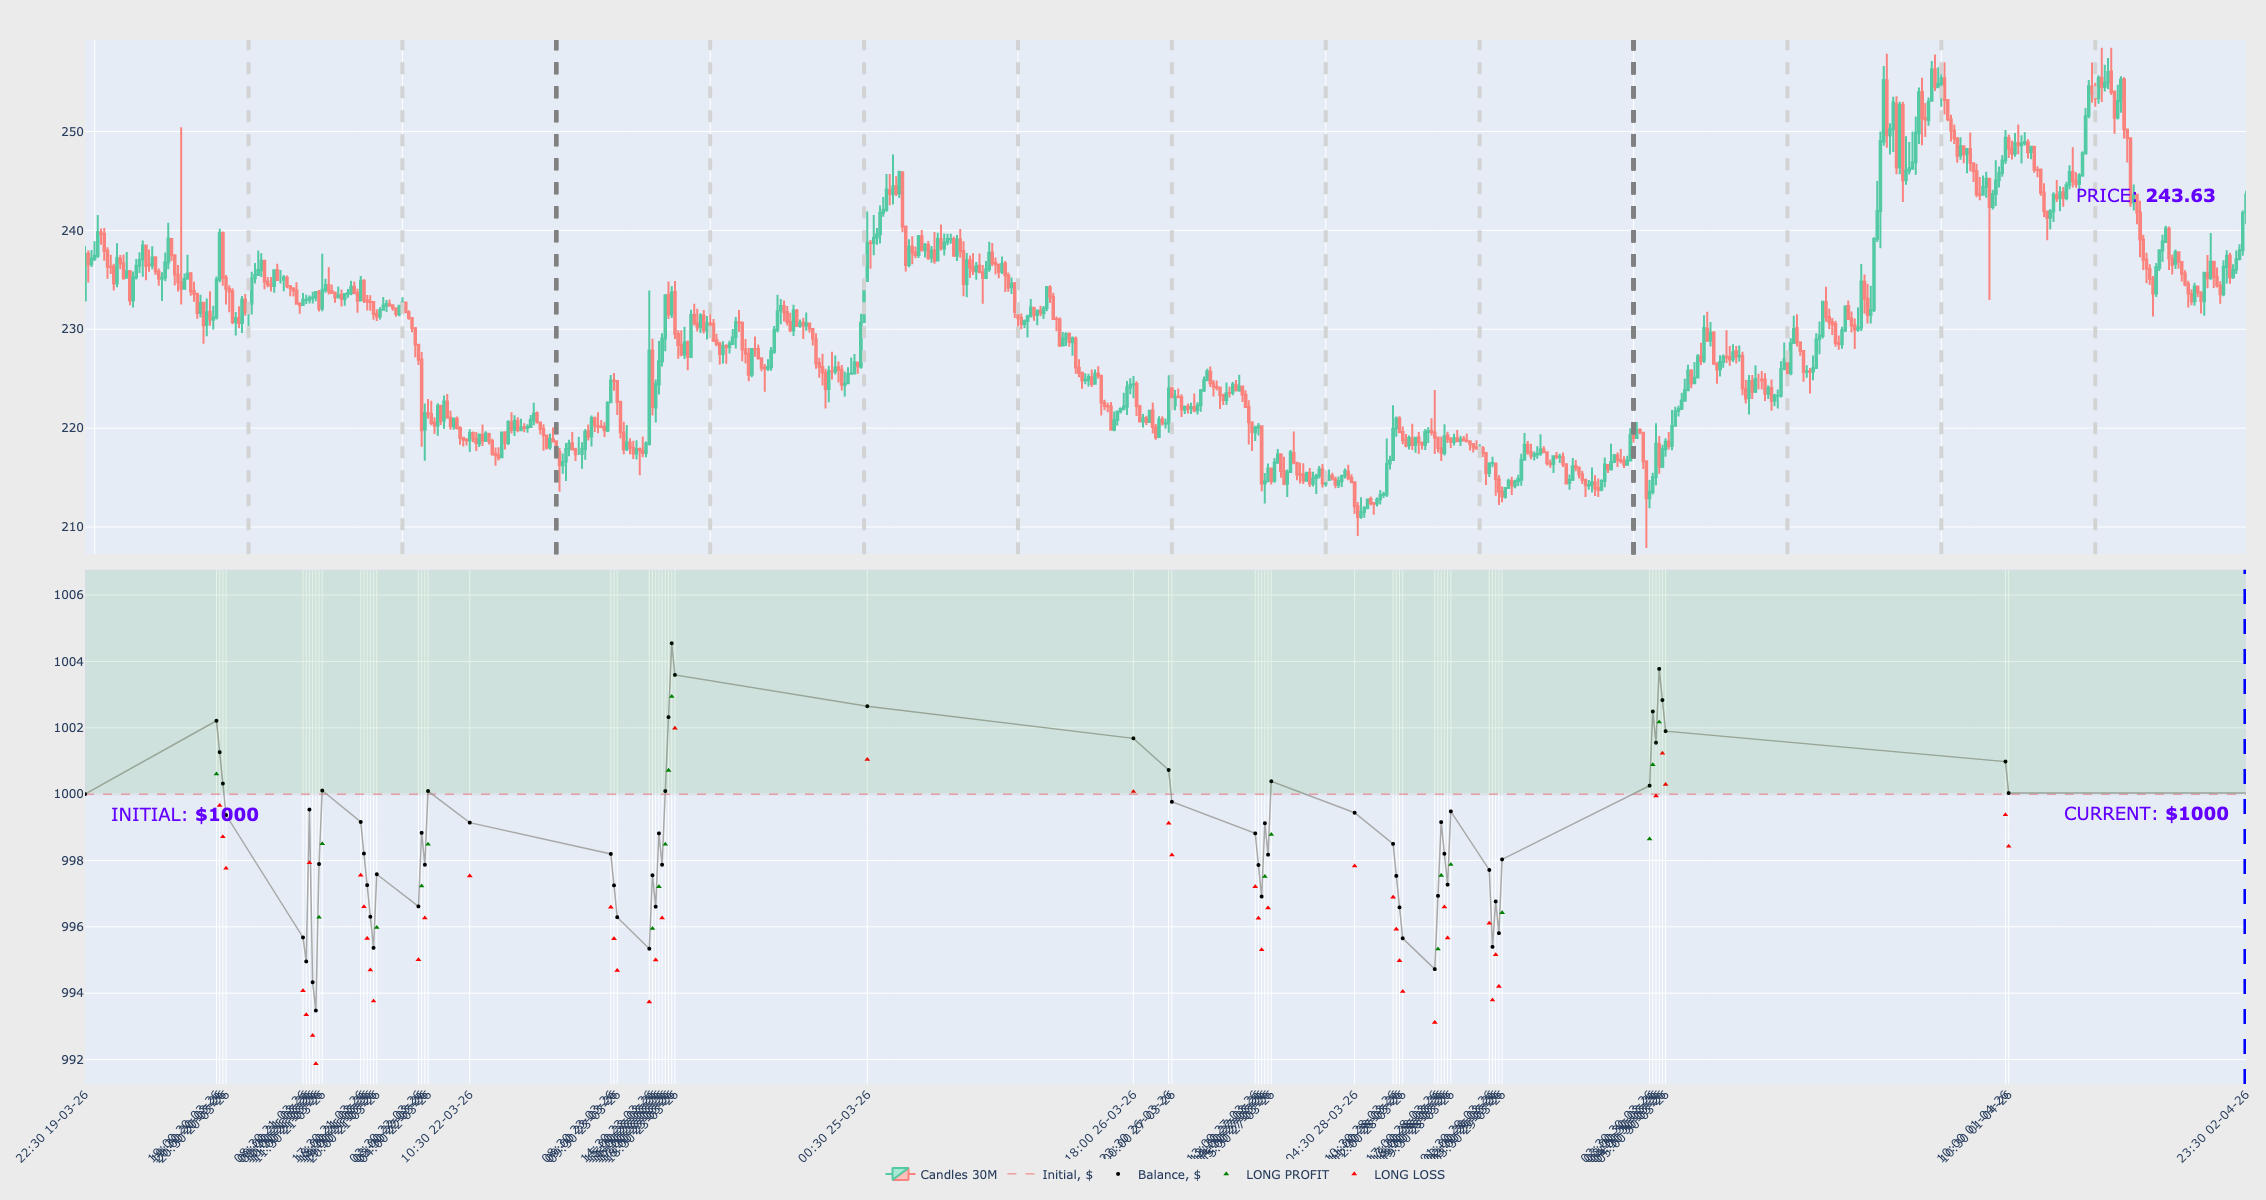

DEBUG [91629:MainThread|2026-04-02 23:57:40 +03]: JOIN: ZECUSDT | SLASH: ZEC/USDT | DASH: ZEC_USDT


MARGIN__REGIME_MOCK__INF_DISCR_30M__FEE_0.036-0.036|ZEC_USDT|GradExplosionTest_71|af786


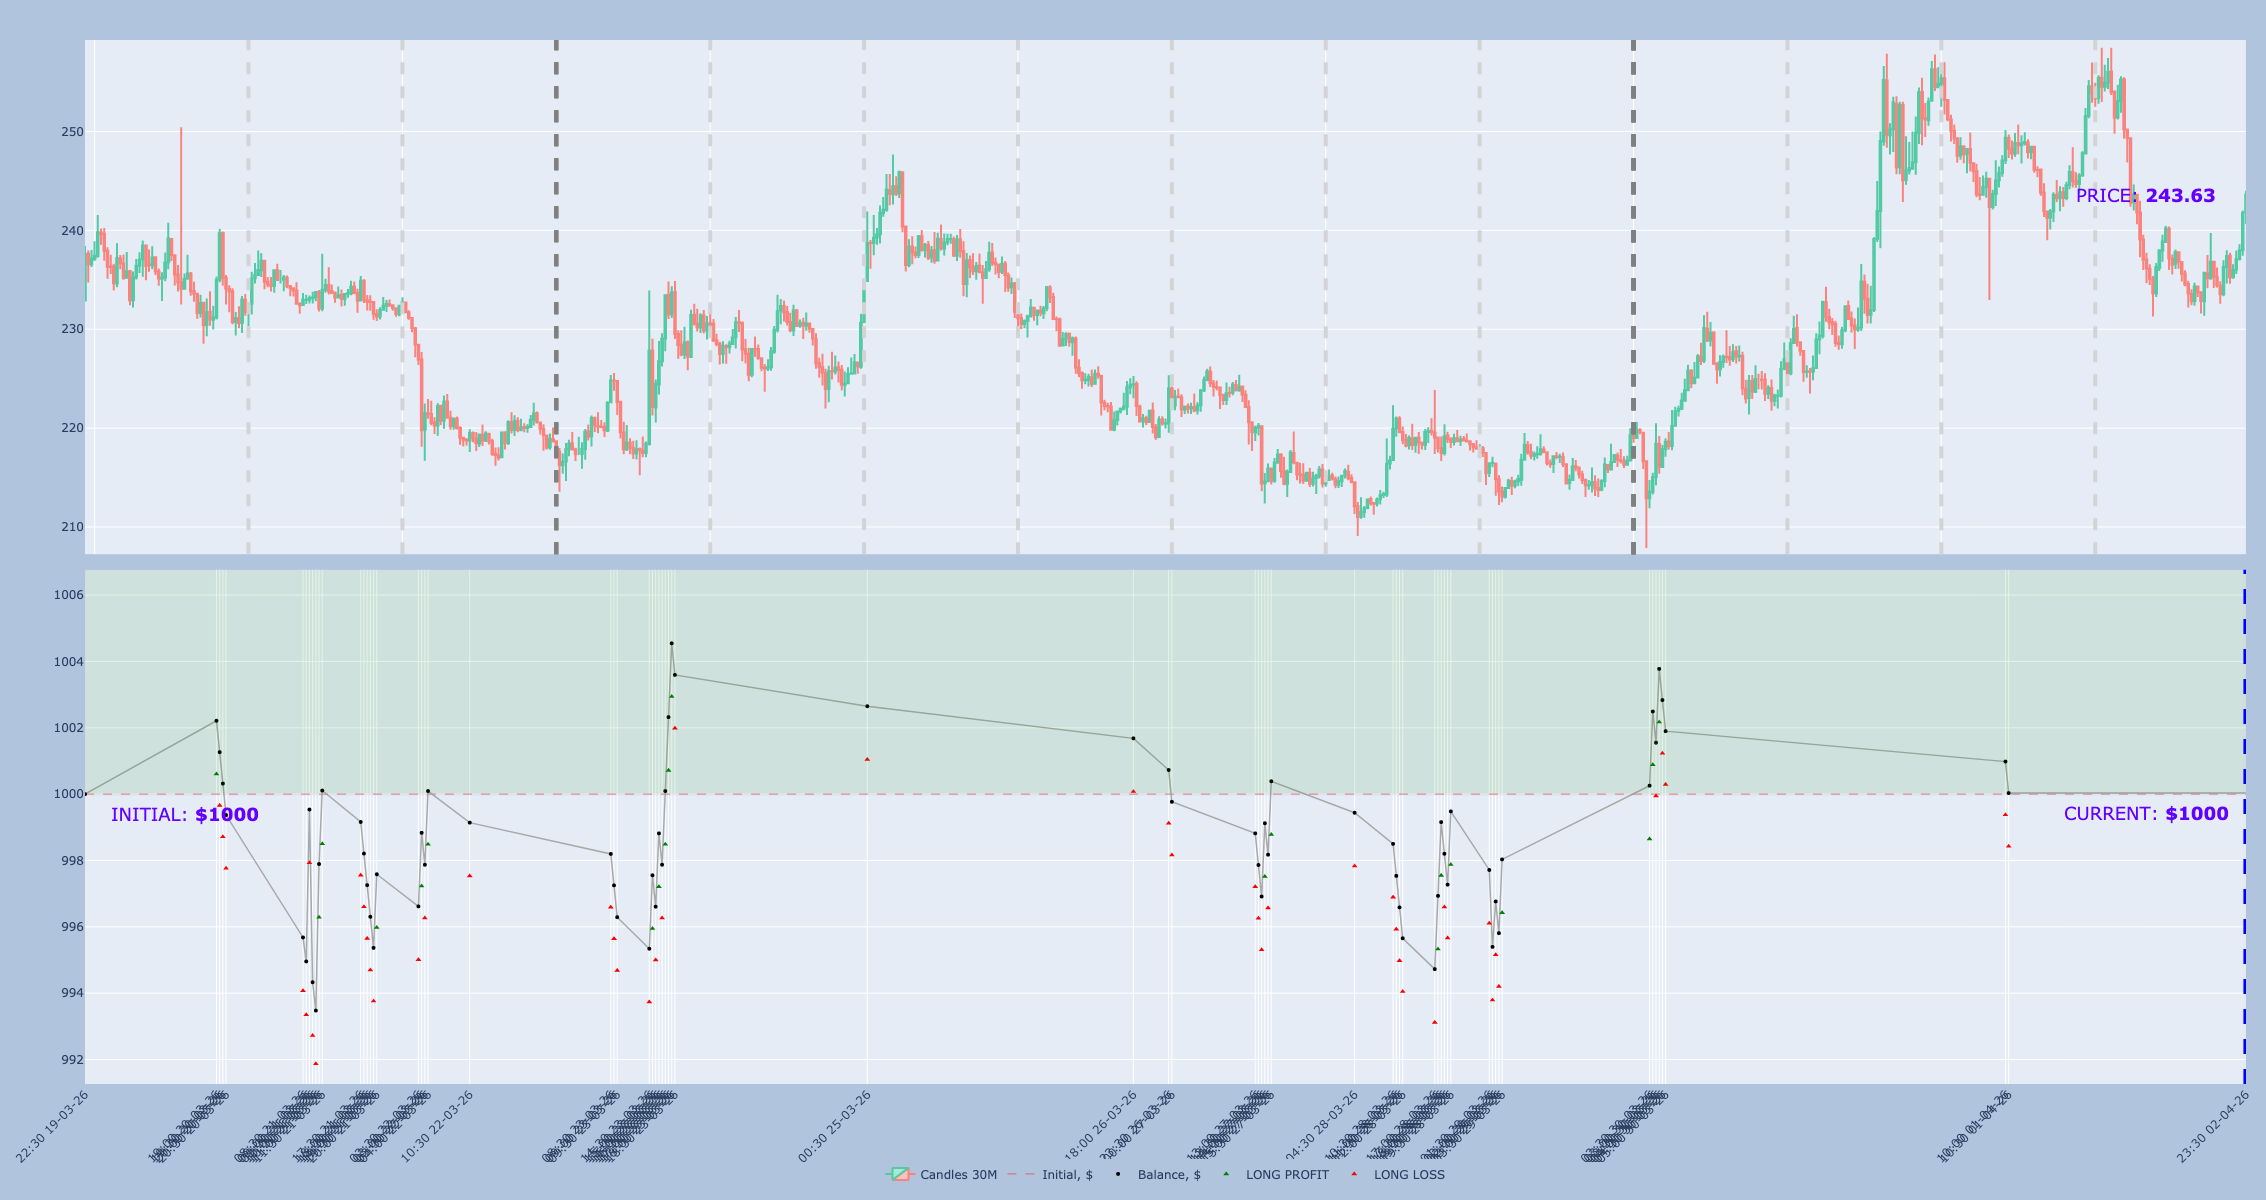

DEBUG [91629:MainThread|2026-04-02 23:57:42 +03]: JOIN: ZECUSDT | SLASH: ZEC/USDT | DASH: ZEC_USDT
DEBUG [91629:MainThread|2026-04-02 23:57:44 +03]: JOIN: ZECUSDT | SLASH: ZEC/USDT | DASH: ZEC_USDT


ERROR DRAWING: MARGIN__REGIME_MOCK__INF_DISCR_30M__FEE_0.036-0.036|ZEC_USDT|GradExplosionTest_72|42261 | Expecting value: line 1 column 1 (char 0)
MARGIN__REGIME_MOCK__INF_DISCR_15M__FEE_0.0-0.0|ZEC_USDT|GradExplosionTest_7|8f5bf


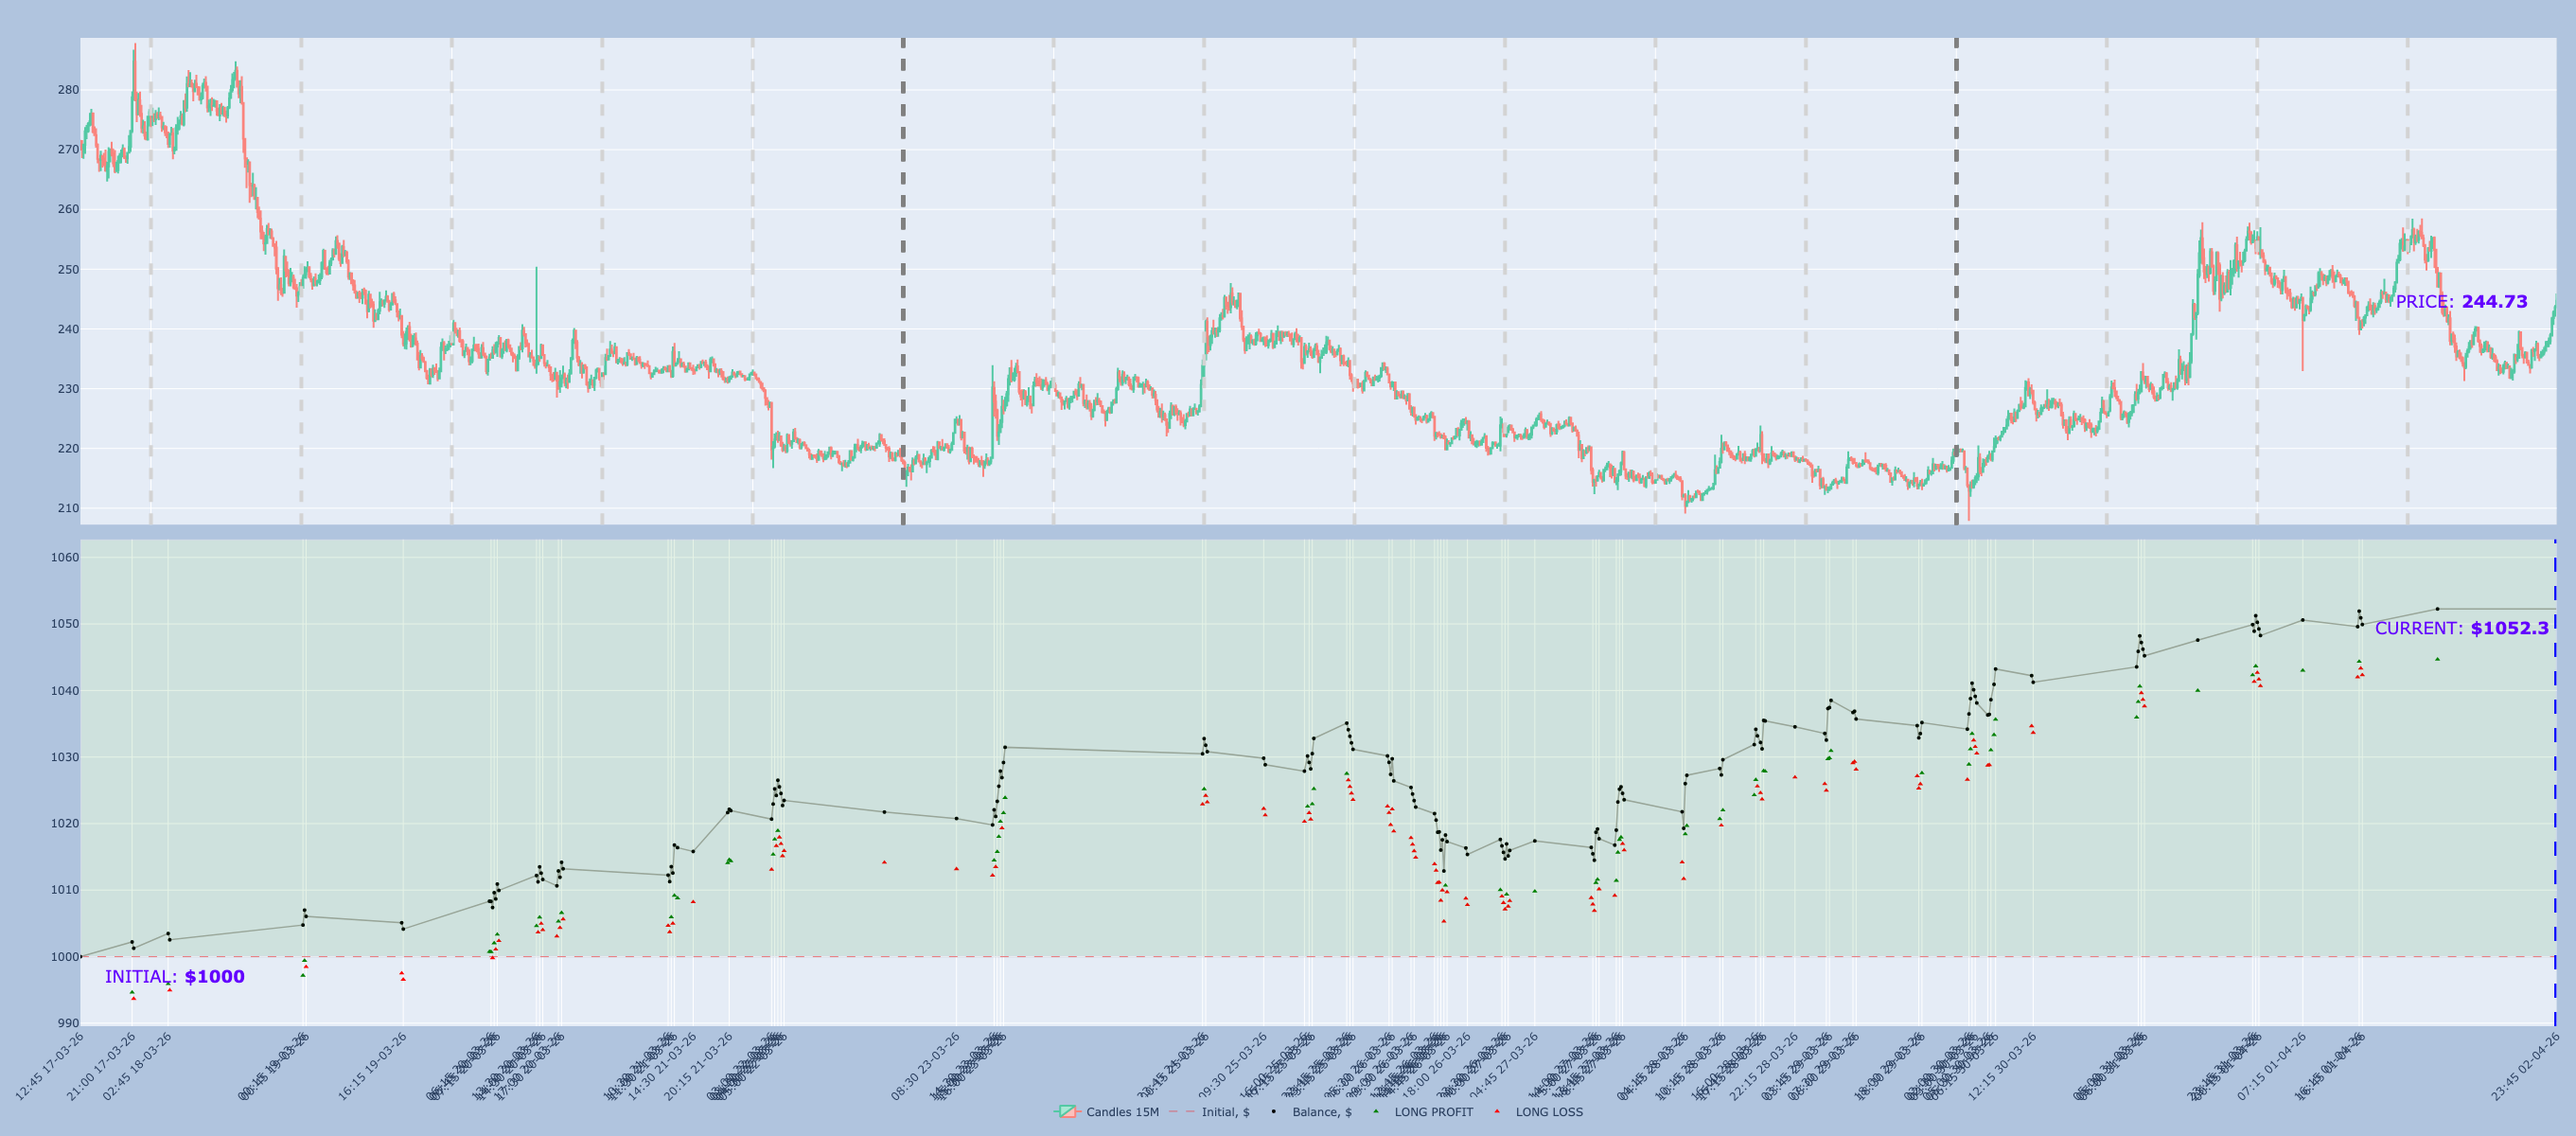

DEBUG [91629:MainThread|2026-04-02 23:57:49 +03]: JOIN: ZECUSDT | SLASH: ZEC/USDT | DASH: ZEC_USDT


MARGIN__REGIME_MOCK__INF_DISCR_15M__FEE_0.036-0.036|ZEC_USDT|GradExplosionTest_7|4a898


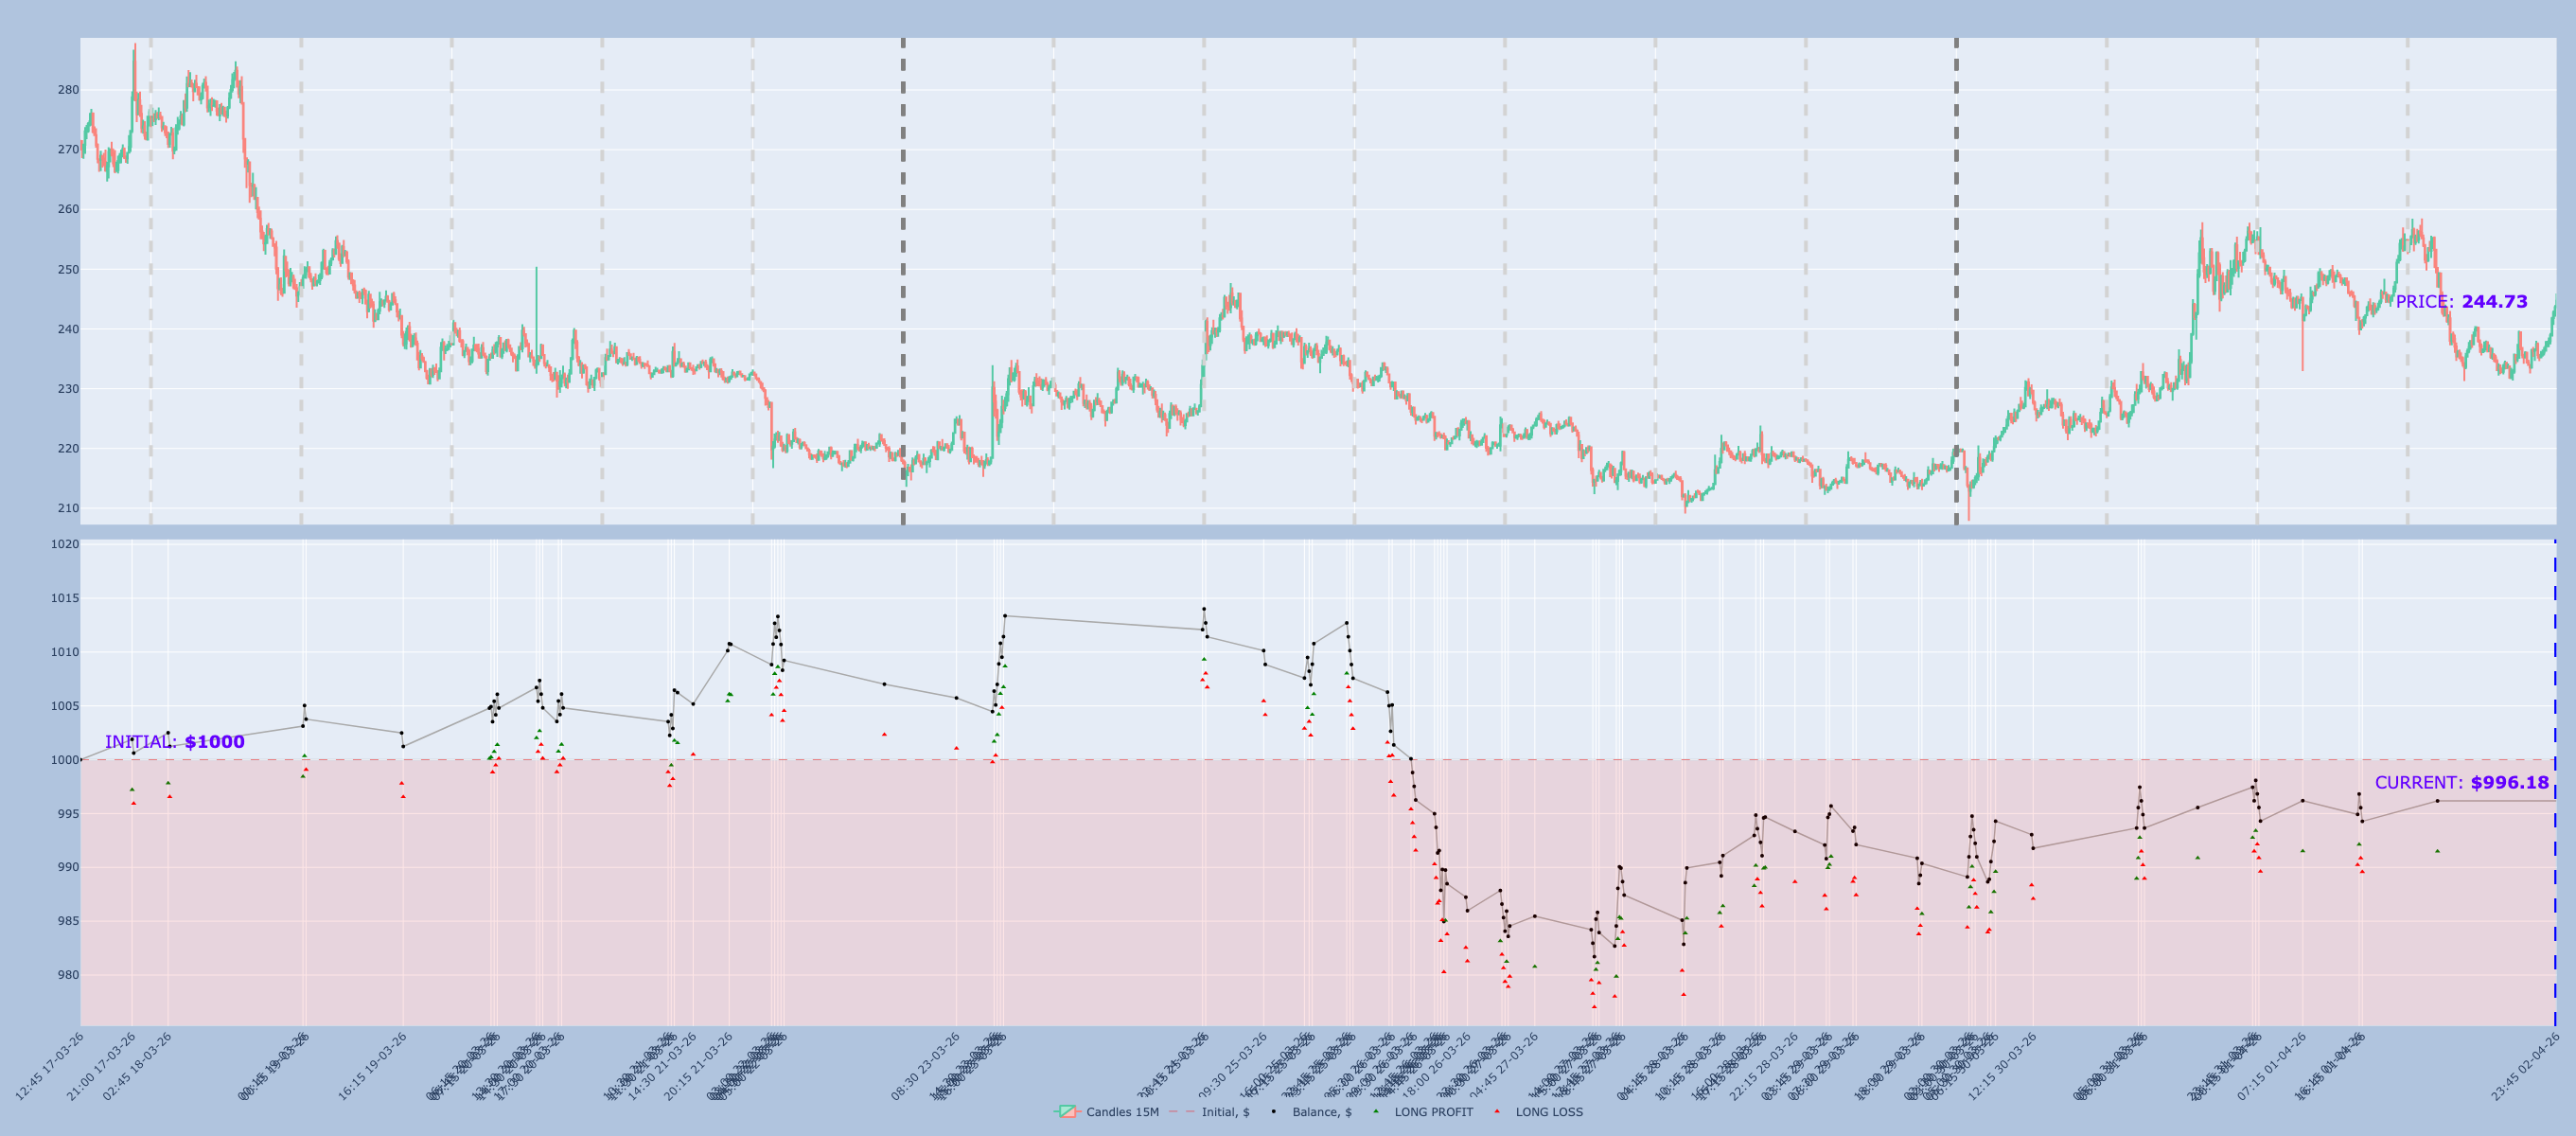

DEBUG [91629:MainThread|2026-04-02 23:57:52 +03]: JOIN: ZECUSDT | SLASH: ZEC/USDT | DASH: ZEC_USDT


MARGIN__REGIME_MOCK__INF_DISCR_30M__FEE_0.0-0.0|ZEC_USDT|GradExplosionTest_72|53428


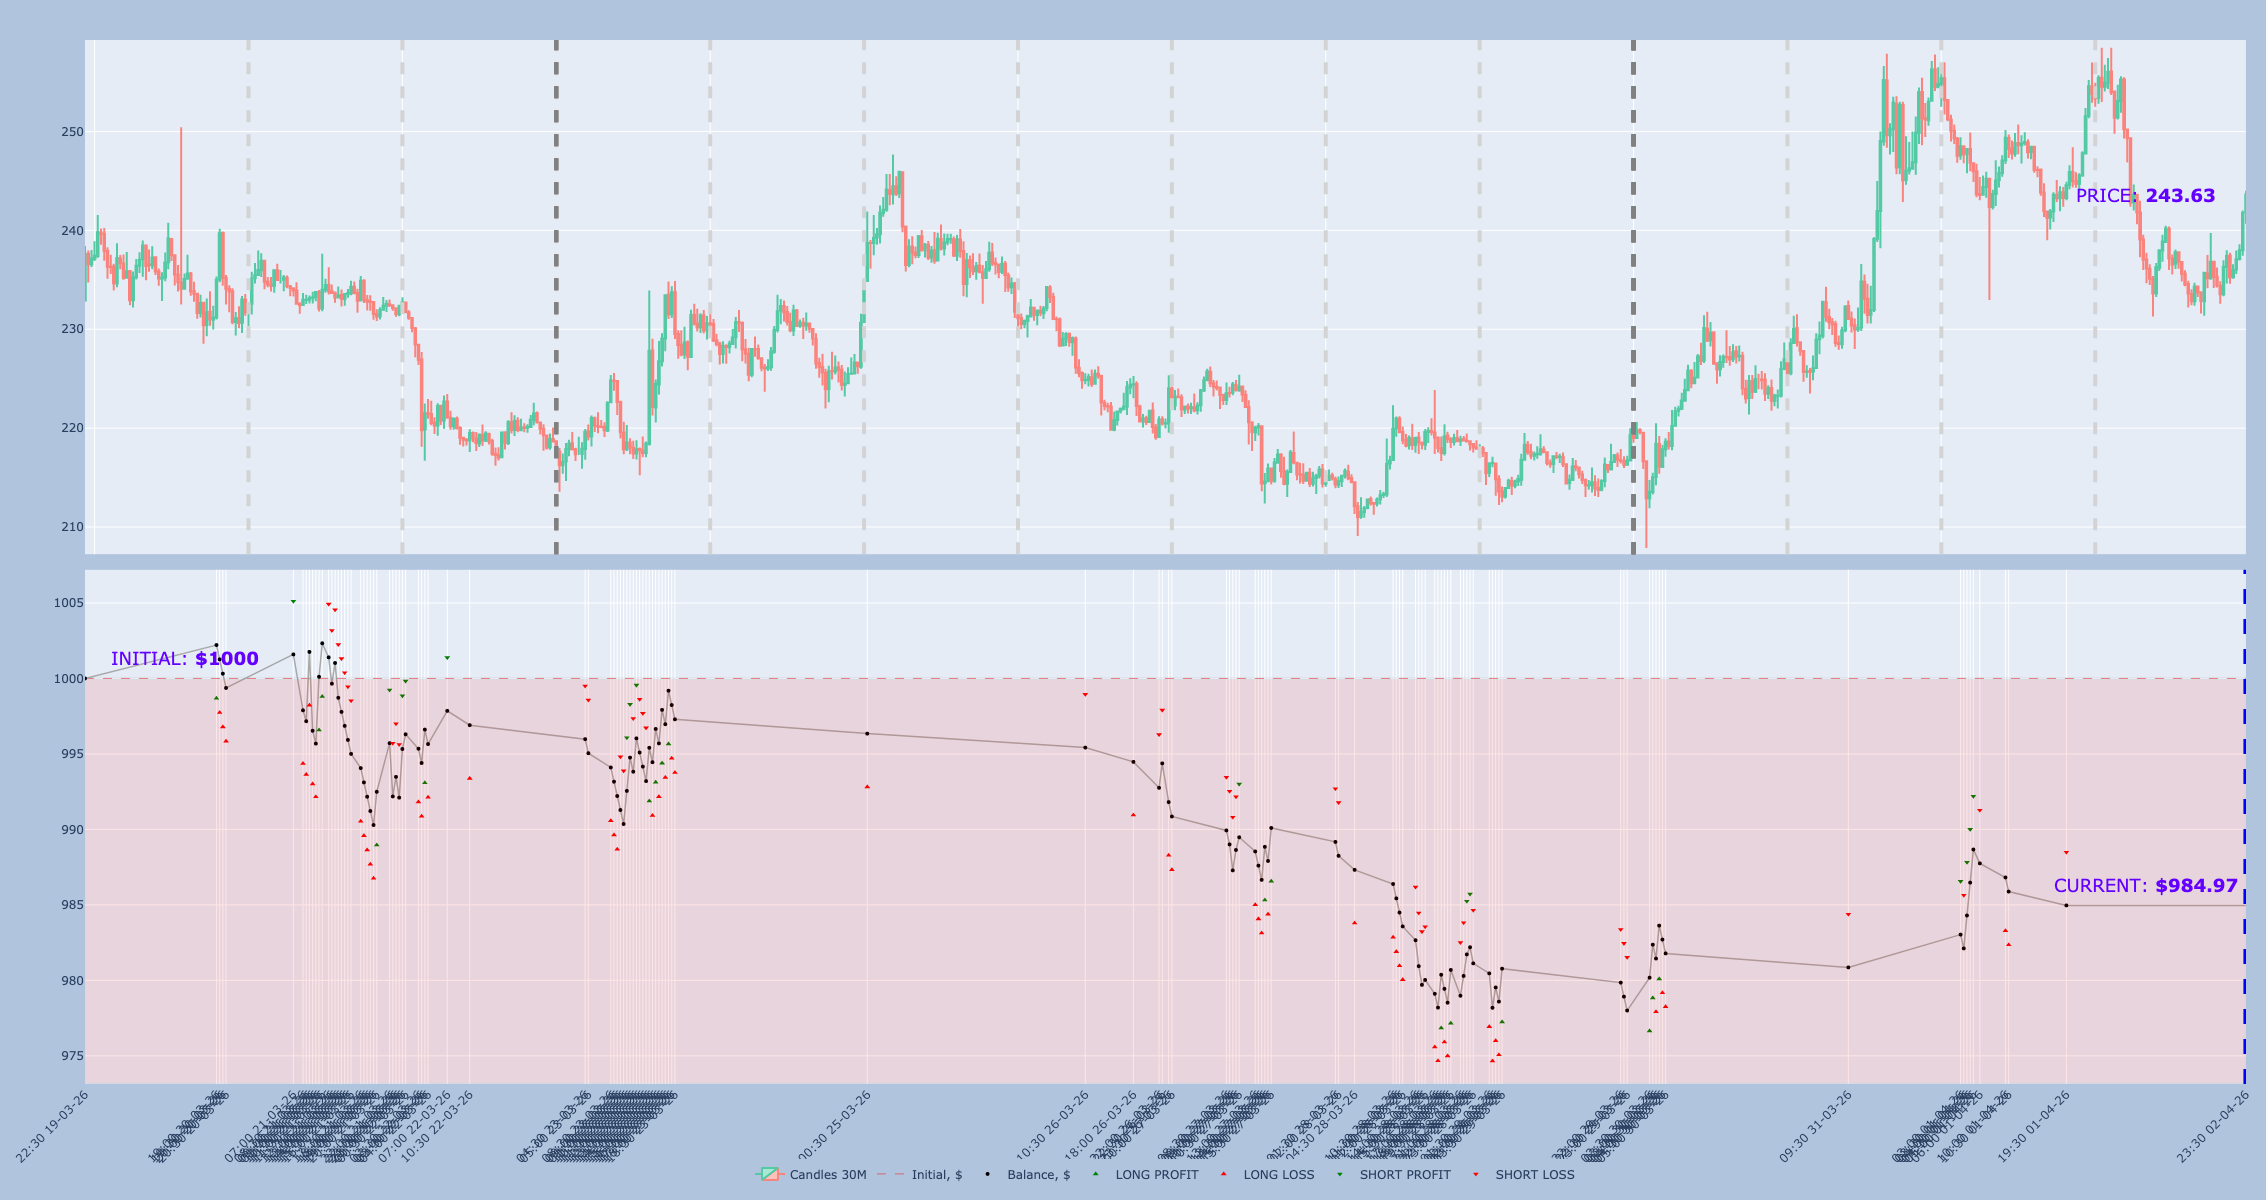

Waiting 60 seconds before clearing output...


In [ ]:
%load_ext autoreload
%autoreload

import os
import math
import time
from SRC.CORE._CONSTANTS import _EXTREMUMS_SUFFIX, _CONFIGS_SUFFIX, _DASHBOARD_SEGMENT, _AUTOMATION_TYPE, _AUTOTRADING
from SRC.WEBAPP.libs.dashboard_app_plot_utils import draw_dashboard_automation_trades_fig
from SRC.CORE._CONSTANTS import EXTREMUNS_FILE_PATH, project_root_dir, USE_GPU, _USE_GPU_DATA_PARALLEL, BINANCE_TAKER_COMISSION, MODEL_FOLDER_PATH, _EXTREMUMS_SUFFIX, _DASHBOARD_SEGMENT, _MARKET_TYPE, _AUTOMATION_TYPE
from IPython.display import Image, display
from IPython.core.display_functions import clear_output
from SRC.WEBAPP.libs.dashboard_app_plot_utils import produce_trade_info_str
from IPython.display import Markdown, display, HTML

from SRC.CORE.debug_utils import SET_DEBUG_LOGLEVEL
from SRC.CORE._CONSTANTS import _TRADES_DF_FIG_IMG_FILE_PATH
from SRC.CORE.debug_utils import printmd
from SRC.LIBRARIES.new_utils import produce_net_folder, is_running, get_net_folder_s
from SRC.LIBRARIES.new_utils import get_netfolder_by_hash
from SRC.WEBAPP.libs.dashboard_app_plot_utils import draw_dashboard_automation_trades_fig

SET_DEBUG_LOGLEVEL()

os.environ['EXTREMUMS_SUFFIX'] = 'stage4'
os.environ['CONFIGS_SUFFIX'] = 'stage4'
os.environ['DASHBOARD_SEGMENT'] = 'BACKTESTING'
os.environ['AUTOMATION_TYPE'] = 'BACKTESTING'

empty_net_d = {}
refresh_timeout_secs = 60
alive_time_threshold = '5M'
while True:
    net_folder_s = get_net_folder_s('BACKTESTING')
    running_net_folder_s = [net_folder for net_folder in net_folder_s if is_running(net_folder, alive_time_threshold)]
    for running_net_folder in running_net_folder_s:
        try:
            net_folder = running_net_folder.replace(" | ", "|")
            transactions_info = draw_dashboard_automation_trades_fig(running_net_folder, intercept_errors=True, empty_net_d=empty_net_d, force_draw=True)
            if not transactions_info:
                print(f"No transactions info for net_folder: {net_folder}")
                continue

            transactions_info_present = produce_trade_info_str(transactions_info)

            trades_df_fig_file_path = _TRADES_DF_FIG_IMG_FILE_PATH()
            printmd(net_folder)
            display(HTML(produce_trade_info_str(transactions_info)))
            display(Image(filename=trades_df_fig_file_path))
        except Exception as ex:
            print(f"ERROR DRAWING: {running_net_folder} | {str(ex)}")

    print(f"Waiting {refresh_timeout_secs} seconds before clearing output...")
    time.sleep(refresh_timeout_secs)
    clear_output()